In [1]:
import anndata as ad
import scanpy as sc
import numpy as np

In [2]:
dataset = ad.read_h5ad('/mnt/data/lorenzo/FOCUS/ARNEO/merged_spatial_transcriptomics.h5ad')

In [5]:
# Compute PCA and UMAP for the whole dataset
sc.pp.normalize_total(dataset, target_sum=1e4)
sc.pp.log1p(dataset)
sc.pp.scale(dataset, max_value=10)
sc.tl.pca(dataset, svd_solver='arpack')
sc.pp.neighbors(dataset, n_neighbors=10, n_pcs=40)
sc.tl.umap(dataset)

/mnt/data/lorenzo/miniconda3/envs/FOCUS/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


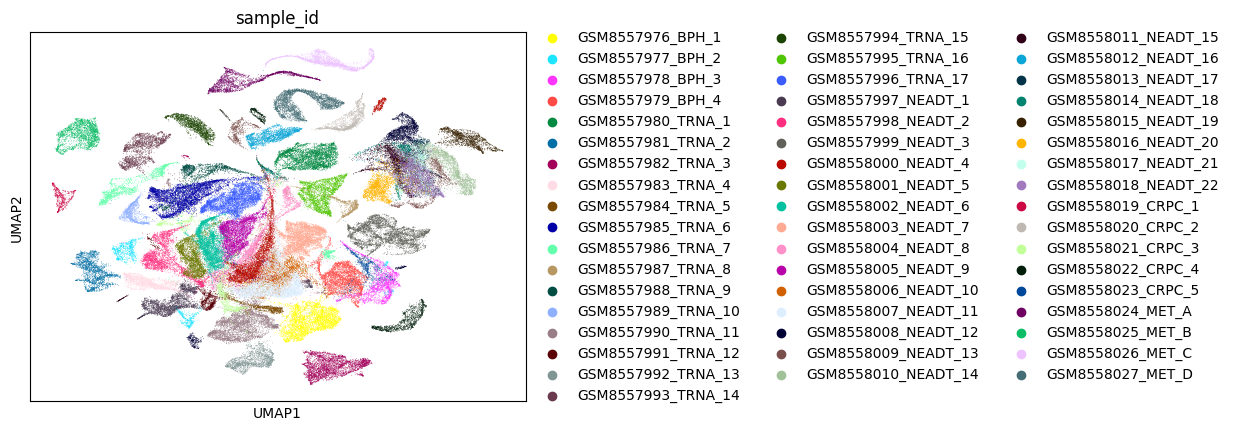

In [6]:
sc.pl.umap(dataset, color=['sample_id'])

In [3]:
filtered_datasets = []

# For each sample in the dataset, filter out spots with low total counts
for sample_id in dataset.obs['sample_id'].unique():
    sample_data = dataset[dataset.obs['sample_id'] == sample_id].copy()
    
    # Calculate total counts per spot
    total_counts = np.array(sample_data.X.sum(axis=1)).flatten()

    # Determine threshold for filtering (e.g., spots with total counts below 10th percentile)
    threshold = np.percentile(total_counts, 5)

    # Filter spots
    filtered_sample_data = sample_data[total_counts >= threshold].copy()
    filtered_datasets.append(filtered_sample_data)

# Concatenate all filtered datasets
filtered_dataset = ad.concat(filtered_datasets)

In [4]:
from scipy import sparse
import numpy as np
from numba import njit, prange

@njit(parallel=True)
def count_expressed_parallel(data, indices, indptr, n_vars):
    """Count non-zero entries per column in CSR format"""
    expressed_counts = np.zeros(n_vars, dtype=np.int32)
    
    for col in prange(n_vars):
        count = 0
        for row in range(len(indptr) - 1):
            row_start = indptr[row]
            row_end = indptr[row + 1]
            for idx in range(row_start, row_end):
                if indices[idx] == col and data[idx] > 0:
                    count += 1
        expressed_counts[col] = count
    
    return expressed_counts

# Ottimizzato per CSR
if not sparse.isspmatrix_csr(filtered_dataset.X):
    X = filtered_dataset.X.tocsr()
else:
    X = filtered_dataset.X

sample_ids = filtered_dataset.obs['sample_id'].values
unique_samples = np.unique(sample_ids)
n_vars = filtered_dataset.n_vars

feature_filter = np.zeros(n_vars, dtype=bool)

for sample_id in unique_samples:
    sample_mask = (sample_ids == sample_id)
    n_spots = sample_mask.sum()
    
    X_sample = X[sample_mask, :].tocsr()
    
    # Ultra-fast counting with Numba
    expressed_counts = count_expressed_parallel(
        X_sample.data, X_sample.indices, X_sample.indptr, n_vars
    )
    
    expression_ratios = expressed_counts / n_spots
    feature_filter |= (expression_ratios >= 0.02)

print(f"Features passing filter: {feature_filter.sum()} / {n_vars}")

Features passing filter: 18420 / 37407


In [5]:
# Remove the features from the filtered dataset
filtered_dataset = filtered_dataset[:, feature_filter].copy()

/mnt/data/lorenzo/miniconda3/envs/FOCUS/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/data/lorenzo/miniconda3/envs/FOCUS/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


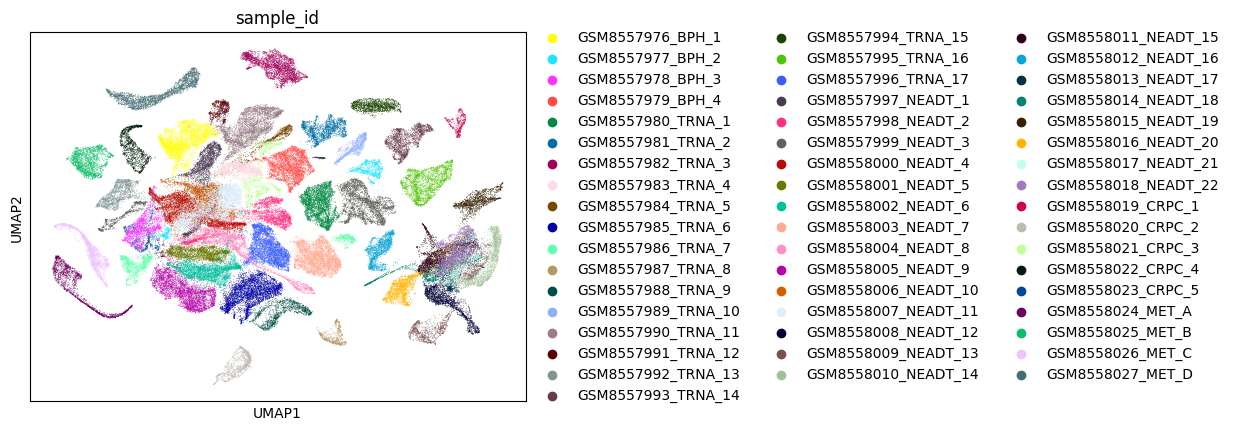

In [6]:
# Now normalize the spots across the filtered dataset to have the same total counts (average total counts used as reference)
sc.pp.normalize_total(filtered_dataset, target_sum=np.mean(np.array(filtered_dataset.X.sum(axis=1)).flatten()))
sc.pp.log1p(filtered_dataset)
sc.pp.scale(filtered_dataset, max_value=10)
sc.tl.pca(filtered_dataset, svd_solver='arpack')
sc.pp.neighbors(filtered_dataset, n_neighbors=10, n_pcs=40)
sc.tl.umap(filtered_dataset)
sc.pl.umap(filtered_dataset, color=['sample_id'])

2025-10-23 11:33:42,892 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-23 11:33:48,288 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-23 11:33:48,720 - harmonypy - INFO - Iteration 1 of 10
2025-10-23 11:34:20,048 - harmonypy - INFO - Iteration 2 of 10
2025-10-23 11:34:50,999 - harmonypy - INFO - Iteration 3 of 10
2025-10-23 11:35:22,544 - harmonypy - INFO - Iteration 4 of 10
2025-10-23 11:35:53,771 - harmonypy - INFO - Iteration 5 of 10
2025-10-23 11:36:24,702 - harmonypy - INFO - Converged after 5 iterations


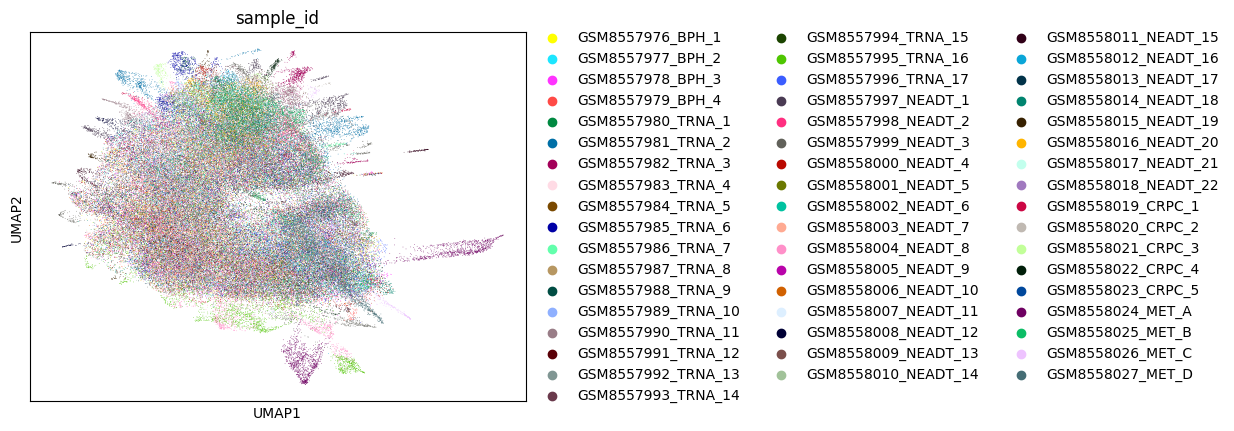

In [10]:
import scanpy.external as sce
# Harmony batch correction
sce.pp.harmony_integrate(
    filtered_dataset, 
    key='sample_id',  # La colonna con i batch IDs
    basis='X_pca',     # Corregge i PC
    adjusted_basis='X_pca_harmony'  # Nome dell'output
)

# Usa i PC corretti per downstream analysis
sc.pp.neighbors(filtered_dataset, n_neighbors=10, use_rep='X_pca_harmony')
sc.tl.umap(filtered_dataset)
sc.pl.umap(filtered_dataset, color=['sample_id'])

/tmp/ipykernel_236567/3870861478.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(filtered_dataset, resolution=0.5)


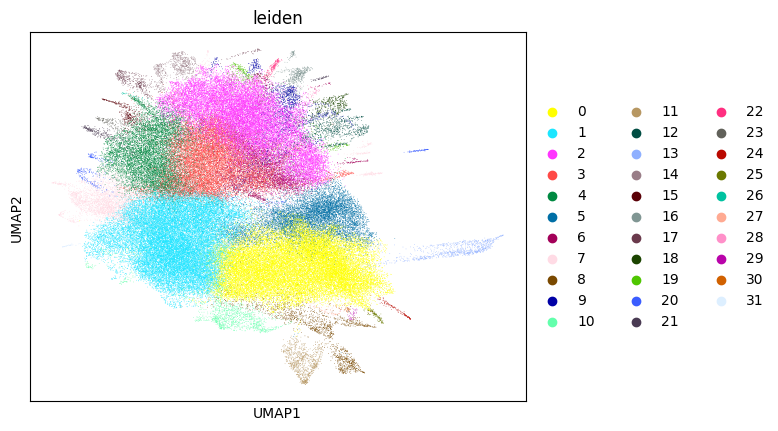

In [11]:
# Compute Leiden clusters on the batch-corrected data
sc.tl.leiden(filtered_dataset, resolution=0.5)
sc.pl.umap(filtered_dataset, color=['leiden'])


In [33]:
# Save the processed dataset
filtered_dataset.write_h5ad('/mnt/data/lorenzo/FOCUS/ARNEO/filtered_batch_corrected_spatial_transcriptomics.h5ad')